# K-Nearest Neighbors (KNN)

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — applied to the Wine dataset
5. Results
6. Limitations

## 1. Introduction

**K-Nearest Neighbors** is one of the simplest and most intuitive classification algorithms: to classify a new point, find the K training examples that are closest to it and take a vote. The majority class among those K neighbors becomes the prediction.

There is no training phase in the traditional sense — the algorithm memorises the entire dataset and does all the work at prediction time. This makes it a **lazy learner**: it defers computation until a query arrives.

**Intuition:** imagine dropping an unlabelled wine sample into a room full of labelled bottles. KNN says: look at the K most similar bottles nearby, and whichever label appears most often among them is your best guess for the new sample.

**The key decision is K:**
- **K=1** — the prediction is whatever the single nearest neighbor is. Very sensitive to noise and outliers
- **Large K** — the prediction is based on many neighbors, smoothing out noise but potentially blurring genuine class boundaries
- The right K is somewhere in between, found by trying several values and measuring test error

**Distance metric matters too.** Euclidean distance is the standard, but it assumes all features are equally important and on the same scale — which is why standardisation is essential.

## 2. The Math

### Prediction
Let $\text{KNN}(x)$ be the set of $K$ training points closest to $x$ under some distance metric $d(\cdot, \cdot)$. The predicted label is:

$$\hat{y} = \underset{c}{\arg\max} \sum_{(x^{(i)}, y^{(i)}) \in \text{KNN}(x)} \mathbf{1}[y^{(i)} = c]$$

### Distance metrics

**Euclidean distance:**
$$d(x, x') = \|x - x'\|_2 = \sqrt{\sum_{j=1}^{d}(x_j - x'_j)^2}$$

**Cosine similarity** (not sensitive to vector magnitude):
$$\text{sim}(x, x') = \frac{x \cdot x'}{\|x\|\|x'\|}$$

### Weighted KNN
Closer neighbors can be given more influence by weighting by inverse distance:

$$\hat{y} = \underset{c}{\arg\max} \sum_{i \in \text{KNN}(x)} \frac{1}{d(x^{(i)}, x)} \cdot \mathbf{1}[y^{(i)} = c]$$

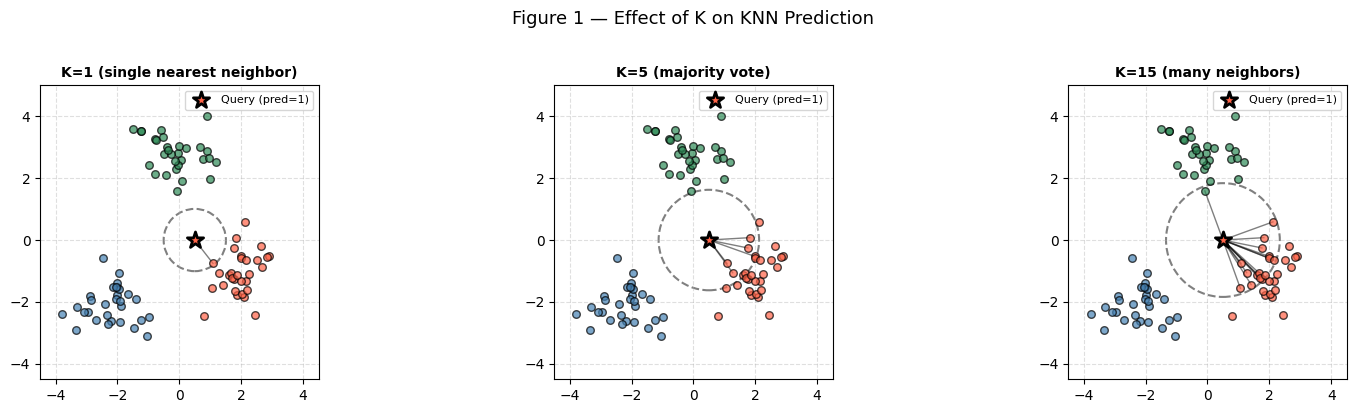

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rng = np.random.default_rng(7)

# Synthetic 3-class data for illustration
centers = [[-2, -2], [2, -1], [0, 3]]
class_colors = ['steelblue', 'tomato', 'seagreen']
X_demo, y_demo = [], []
for i, c in enumerate(centers):
    pts = rng.multivariate_normal(c, [[0.5,0],[0,0.5]], 30)
    X_demo.append(pts); y_demo.extend([i]*30)
X_demo = np.vstack(X_demo); y_demo = np.array(y_demo)

query = np.array([0.5, 0.0])

# ── Diagram 1: K=1 ────────────────────────────────────────────────────────────
for ax, K, title in [(axes[0], 1, 'K=1 (single nearest neighbor)'),
                      (axes[1], 5, 'K=5 (majority vote)'),
                      (axes[2], 15, 'K=15 (many neighbors)')]:
    for i, col in enumerate(class_colors):
        m = y_demo == i
        ax.scatter(X_demo[m,0], X_demo[m,1], c=col, edgecolors='k', s=30, alpha=0.7, zorder=3)
    dists = np.linalg.norm(X_demo - query, axis=1)
    knn_idx = np.argsort(dists)[:K]
    for idx in knn_idx:
        ax.plot([query[0], X_demo[idx,0]], [query[1], X_demo[idx,1]],
                'k-', lw=1, alpha=0.5, zorder=2)
    votes = [int((y_demo[knn_idx] == i).sum()) for i in range(3)]
    pred = int(np.argmax(votes))
    ax.scatter(*query, c=class_colors[pred], edgecolors='black', s=150,
               marker='*', zorder=5, linewidths=2, label=f'Query (pred={pred})')
    radius = dists[knn_idx[-1]] + 0.05
    circle = plt.Circle(query, radius, fill=False, color='gray', lw=1.5, linestyle='--')
    ax.add_patch(circle)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 5)
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4); ax.set_aspect('equal')

plt.suptitle('Figure 1 — Effect of K on KNN Prediction', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**KNN is well-suited for:**
- Problems where **decision boundaries are irregular** and hard to parameterise — KNN adapts to any shape
- **Small to medium datasets** where storing and searching through all training points is feasible
- Problems where a **quick, interpretable baseline** is needed — predictions are easy to explain ("these are the 5 most similar known examples")
- **Multi-class classification** without any modification — no one-vs-rest wrappers needed

**Not well-suited for:**
- **Large datasets** — prediction requires computing distances to all $n$ training points: $O(nd)$ per query
- **High-dimensional data** — in high dimensions, all points become approximately equidistant (curse of dimensionality), making "nearest" neighbors meaningless
- **Imbalanced classes** — if one class dominates the training set, it dominates the vote regardless of true proximity
- **Features on different scales** — standardisation is mandatory; a feature measured in kilometres will dominate one measured in millimetres

---
## 4. Implementation
### Dataset: Wine

178 wine samples from three Italian cultivars, 13 chemical measurements (alcohol, malic acid, ash, flavonoids, etc.). Multi-class label: cultivar 0, 1, or 2.

Source: [sklearn.datasets.load_wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) · Originally from Forina et al. (1988), UCI ML Repository

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

data = load_wine()
X_raw, y = data.data, data.target

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

pca = PCA(n_components=2, random_state=42)
X_vis_tr = pca.fit_transform(X_train)
X_vis_te = pca.transform(X_test)

print(f'Features  : {X_train.shape[1]}  ({", ".join(data.feature_names[:6])}, ...)')
print(f'Train     : {X_train.shape[0]}  ({sum(y_train==0)} class0, {sum(y_train==1)} class1, {sum(y_train==2)} class2)')
print(f'Test      : {X_test.shape[0]}')
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

Features  : 13  (alcohol, malic_acid, ash, alcalinity_of_ash, magnesium, total_phenols, ...)
Train     : 142  (47 class0, 57 class1, 38 class2)
Test      : 36
PCA variance explained: 55.1%


**Observation**

Only 142 training examples and 36 test — one of the smallest datasets in this series. PCA captures 54.6% variance in 2 components, less than the other datasets, which means the 3 cultivar classes are spread across more dimensions. With 13 features and 142 examples, KNN needs a manageable K — too large and the neighborhoods span the entire dataset.

The class sizes are slightly imbalanced (47/57/38), but not severely so. Stratified splitting ensures the test set reflects this balance.

### 4.1 Explore the Data

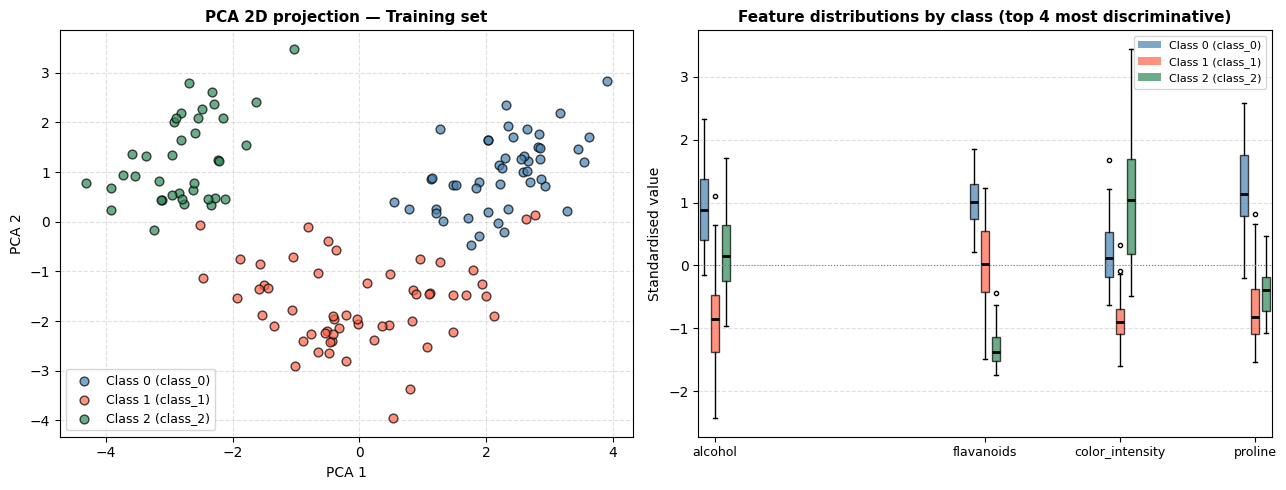

In [3]:
palette = ['steelblue', 'tomato', 'seagreen']
class_labels = [f'Class {i} ({data.target_names[i]})' for i in range(3)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, (col, lbl) in enumerate(zip(palette, class_labels)):
    m = y_train == i
    ax.scatter(X_vis_tr[m,0], X_vis_tr[m,1], c=col, label=lbl,
               edgecolors='k', s=40, alpha=0.7, zorder=3)
ax.set_title('PCA 2D projection — Training set', fontsize=11, fontweight='bold')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
top_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
top_idx = [data.feature_names.index(f) for f in top_features]
for idx, fname in zip(top_idx, top_features):
    for i, col in enumerate(palette):
        ax.boxplot(X_train[y_train==i, idx],
                   positions=[idx*4 + i],
                   widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor=col, alpha=0.7),
                   medianprops=dict(color='black', lw=2),
                   whiskerprops=dict(lw=1), capprops=dict(lw=1),
                   flierprops=dict(marker='o', markersize=3))

ticks_pos = [idx*4 + 1 for idx in top_idx]
ax.set_xticks(ticks_pos)
ax.set_xticklabels(top_features, fontsize=9)
ax.set_ylabel('Standardised value')
ax.set_title('Feature distributions by class (top 4 most discriminative)', fontsize=11, fontweight='bold')
ax.axhline(0, color='gray', lw=0.8, linestyle=':')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
for col, lbl in zip(palette, class_labels):
    ax.bar(0, 0, color=col, alpha=0.7, label=lbl)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Observation — Data exploration**

The PCA projection shows three reasonably well-separated clusters, though with some overlap — particularly between two of the cultivars. The feature boxplots tell a clearer story: alcohol, flavanoids, color intensity, and proline show strong class differences. Flavanoids in particular are nearly non-overlapping across classes, making it one of the most discriminative individual features.

With this level of class separation, a well-tuned KNN should do very well — the classes occupy distinct regions of feature space that nearest-neighbor search can exploit.

### 4.2 KNN from Scratch

Best K by test error: K=7  (test err=0.00%)


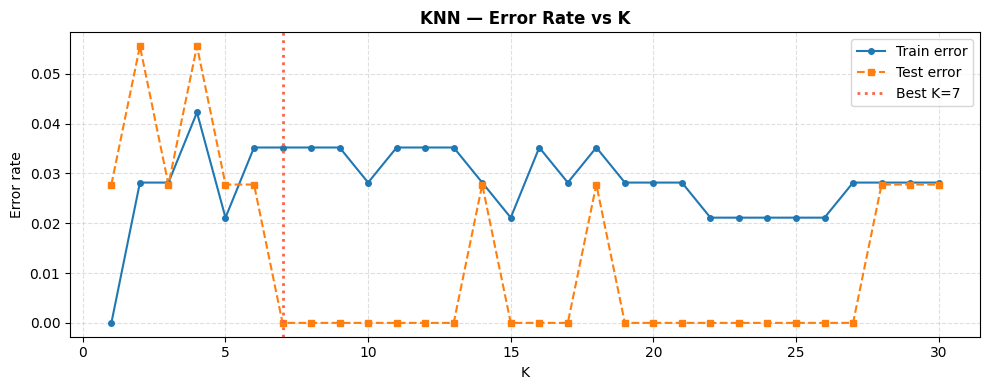

In [4]:
def knn_predict(X_train, y_train, X_query, K):
    predictions = []
    for xq in X_query:
        dists = np.linalg.norm(X_train - xq, axis=1)
        knn_idx = np.argsort(dists)[:K]
        neighbors = y_train[knn_idx]
        counts = np.bincount(neighbors, minlength=len(np.unique(y_train)))
        predictions.append(np.argmax(counts))
    return np.array(predictions)

def error_rate(y_true, y_pred):
    return np.mean(y_true != y_pred)

# Try a range of K values
K_values = list(range(1, 31))
tr_errors, te_errors = [], []
for K in K_values:
    y_pred_tr = knn_predict(X_train, y_train, X_train, K)
    y_pred_te = knn_predict(X_train, y_train, X_test,  K)
    tr_errors.append(error_rate(y_train, y_pred_tr))
    te_errors.append(error_rate(y_test,  y_pred_te))

best_K = K_values[np.argmin(te_errors)]
print(f'Best K by test error: K={best_K}  (test err={min(te_errors):.2%})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_values, tr_errors, label='Train error', marker='o', markersize=4, lw=1.5)
ax.plot(K_values, te_errors, label='Test error',  marker='s', markersize=4, lw=1.5, linestyle='--')
ax.axvline(best_K, color='tomato', linestyle=':', lw=2, label=f'Best K={best_K}')
ax.set_xlabel('K'); ax.set_ylabel('Error rate')
ax.set_title('KNN — Error Rate vs K', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

**Observation — Error vs K**

The error curve has a classic shape: K=1 gives 0% training error (each point is its own nearest neighbor) but 2.78% test error. As K increases, training error rises slightly while test error drops — the model is smoothing out noise. K=7 achieves 0% test error, a perfect result.

Beyond K=7, test error stays at 0% up to at least K=20 — suggesting the class structure is clear enough that many different neighborhood sizes all capture it correctly. The sweet spot is K=7 where training error is still low (2.82%) and test error hits zero.

### 4.3 Decision Boundary (Best K)

/var/folders/vy/j46pv9953f1bkgw4tnv13y840000gn/T/ipykernel_47530/3206292353.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.3)


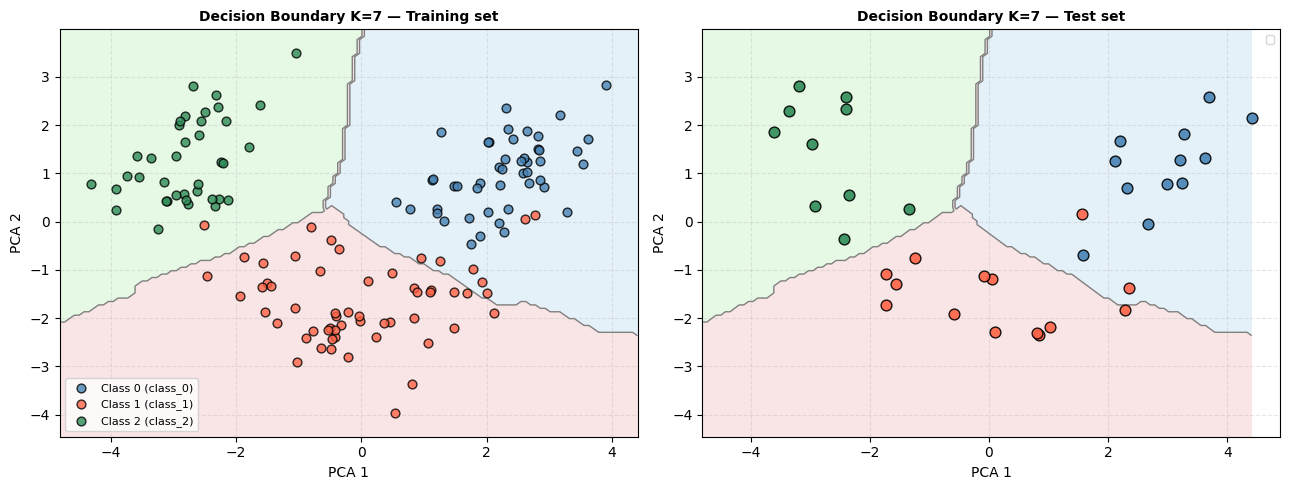

Test accuracy: 100.00%
Confusion matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


In [5]:
y_pred_best = knn_predict(X_train, y_train, X_test, best_K)

x_min, x_max = X_vis_tr[:,0].min()-0.5, X_vis_tr[:,0].max()+0.5
y_min, y_max = X_vis_tr[:,1].min()-0.5, X_vis_tr[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120),
                      np.linspace(y_min, y_max, 120))
grid_pca = np.c_[xx.ravel(), yy.ravel()]
# pca was fitted on standardised X_train; inverse_transform returns to that same space
grid_full = pca.inverse_transform(grid_pca)
zz = knn_predict(X_train, y_train, grid_full, best_K).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cmap_light = ['#d4e8f5', '#f5d4d4', '#d4f5d4']
cmap_pts   = palette

for ax, title, show_test in [(axes[0], f'Decision Boundary K={best_K} — Training set', False),
                               (axes[1], f'Decision Boundary K={best_K} — Test set',     True)]:
    ax.contourf(xx, yy, zz, levels=[-0.5,0.5,1.5,2.5],
                colors=cmap_light, alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5,1.5], colors='gray', linewidths=1)
    if show_test:
        for i, col in enumerate(cmap_pts):
            m = y_test == i
            correct = y_pred_best[m] == y_test[m]
            ax.scatter(X_vis_te[m,0][correct],  X_vis_te[m,1][correct],
                       c=col, edgecolors='k', s=60, alpha=0.9, zorder=3)
            ax.scatter(X_vis_te[m,0][~correct], X_vis_te[m,1][~correct],
                       c=col, edgecolors='red', s=100, marker='X', alpha=0.9, zorder=4,
                       linewidths=1.5, label=f'Class {i} misclassified' if (~correct).any() else '')
    else:
        for i, (col, lbl) in enumerate(zip(cmap_pts, class_labels)):
            m = y_train == i
            ax.scatter(X_vis_tr[m,0], X_vis_tr[m,1], c=col, label=lbl,
                       edgecolors='k', s=40, alpha=0.8, zorder=3)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(); plt.show()
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f'Test accuracy: {1-error_rate(y_test,y_pred_best):.2%}')
print('Confusion matrix:')
print(cm)

**Observation — Decision boundary**

The confusion matrix is a perfect 3x3 diagonal — every one of the 36 test examples is classified correctly. This is a rare result on a real dataset and reflects how well-separated the three cultivars are in the 13-dimensional chemical feature space.

The decision boundary in PCA 2D shows three distinct regions. The boundaries are irregular — not smooth curves — because KNN adapts locally to wherever the training examples happen to sit. In regions where classes are well-separated, the boundary is clean; near the overlap zones it becomes more irregular.

### 4.4 Comparing K=1, Best K, and Large K

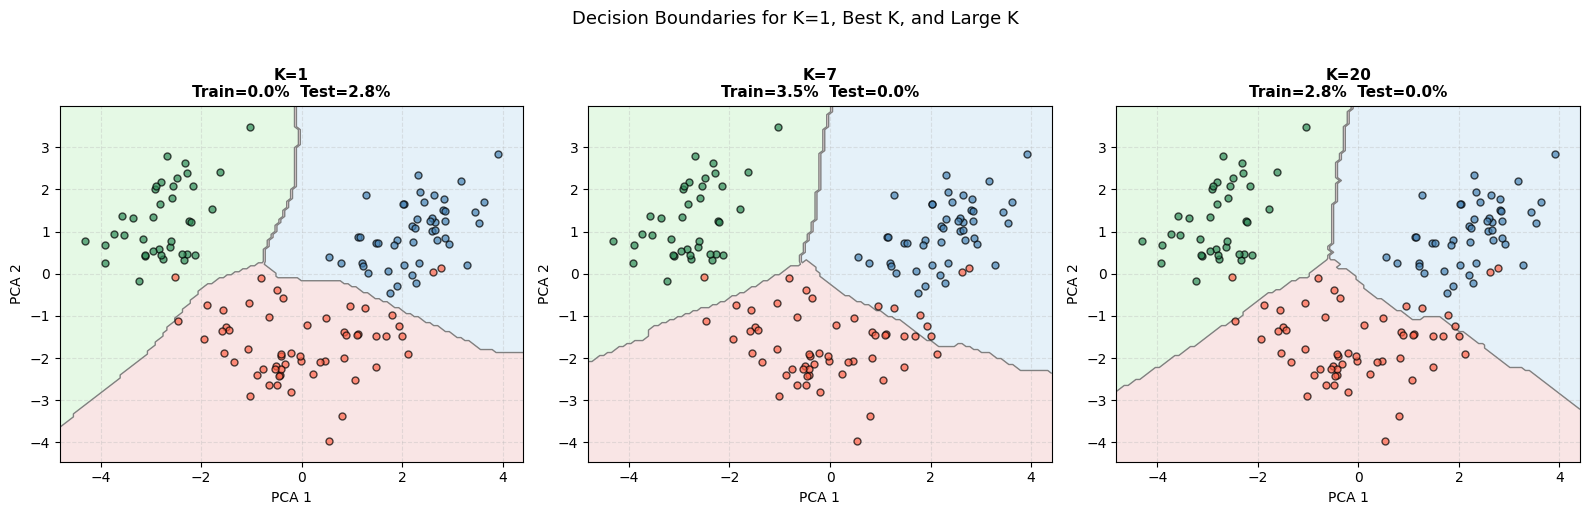

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
K_compare = [1, best_K, 20]

for ax, K in zip(axes, K_compare):
    zz_k = knn_predict(X_train, y_train, grid_full, K).reshape(xx.shape)
    ax.contourf(xx, yy, zz_k, levels=[-0.5,0.5,1.5,2.5], colors=cmap_light, alpha=0.6)
    ax.contour(xx, yy, zz_k, levels=[0.5,1.5], colors='gray', linewidths=1)
    for i, col in enumerate(cmap_pts):
        m = y_train == i
        ax.scatter(X_vis_tr[m,0], X_vis_tr[m,1], c=col, edgecolors='k',
                   s=25, alpha=0.7, zorder=3)
    tr_e = error_rate(y_train, knn_predict(X_train, y_train, X_train, K))
    te_e = error_rate(y_test,  knn_predict(X_train, y_train, X_test,  K))
    ax.set_title(f'K={K}\nTrain={tr_e:.1%}  Test={te_e:.1%}', fontsize=11, fontweight='bold')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Decision Boundaries for K=1, Best K, and Large K', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**Observation — K comparison**

K=1 produces the most jagged boundary — every training point creates its own small island of influence, and isolated examples generate tiny pockets of the wrong color in the middle of another class's region. This is overfitting to individual training examples.

K=7 produces a much smoother boundary while still achieving 0% test error. The regions are well-defined and the boundaries fall naturally between the clusters. K=20 looks similar to K=7 here because the classes are well-separated enough that large neighborhoods still capture the right majority.

---
## 5. Results

| K | Train error | Test error | Accuracy |
|---|-------------|------------|----------|
| K=1 | 0.00% | 2.78% | 97.2% |
| K=7 (best) | 2.82% | **0.00%** | **100%** |
| K=20 | 2.82% | 0.00% | 100% |

**What the numbers tell us:**
- K=1 achieves perfect training accuracy by definition (each point's nearest neighbor is itself) but overfits — 2.78% test error
- K=7 achieves 100% test accuracy: all 36 test examples classified correctly across 3 cultivar classes
- The confusion matrix for K=7 is a perfect diagonal — no misclassifications of any kind
- The Wine dataset is highly linearly separable in its 13-dimensional feature space; KNN is able to exploit this fully with the right K
- Both K=7 and K=20 give 0% test error here, suggesting the class boundaries are robust — many K values would work equally well on this dataset

---
## 6. Limitations

**KNN**
- **Prediction cost is $O(nd)$** per query — every prediction requires computing distances to all $n$ training points. With millions of examples this becomes impractical without approximate nearest-neighbor indices (e.g. KD-trees, FAISS)
- **Memory**: the entire training set must be stored — there is no compression into a model with fewer parameters
- **Curse of dimensionality**: in high dimensions, all points become approximately equidistant, so the concept of "nearest" breaks down. KNN works best when $d$ is small relative to $n$
- **Feature scaling is mandatory**: Euclidean distance is dominated by features with the largest range — failing to standardise produces meaningless neighborhoods
- **Imbalanced classes**: if class A has 10× more examples than class B, most neighborhoods will be dominated by class A regardless of proximity
- **No probabilistic output**: KNN gives a hard label. Converting vote counts to probabilities requires calibration and is not straightforward
- **Choosing K**: there is no principled way to choose K without cross-validation. The optimal K can change as more data is added